In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
import seaborn as sns
import numpy as np

In [7]:
s=pd.read_csv(r"C:\Users\sivas\Downloads\1.04. Real-life example.csv")
s

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4
...,...,...,...,...,...,...,...,...,...
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014,S 350
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999,535
4342,BMW,8000.0,sedan,194,2.0,Petrol,yes,1985,520
4343,Toyota,14200.0,sedan,31,NaN,Petrol,yes,2014,Corolla


In [9]:
s.columns

Index(['Brand', 'Price', 'Body', 'Mileage', 'EngineV', 'Engine Type',
       'Registration', 'Year', 'Model'],
      dtype='object')

In [10]:
o=s["Price"]
o

0         4200.0
1         7900.0
2        13300.0
3        23000.0
4        18300.0
          ...   
4340    125000.0
4341      6500.0
4342      8000.0
4343     14200.0
4344     13500.0
Name: Price, Length: 4345, dtype: float64

In [11]:
s.columns[s.isnull().any()]

Index(['Price', 'EngineV'], dtype='object')

In [12]:
s=s.drop(["EngineV"],axis="columns")
s.columns

Index(['Brand', 'Price', 'Body', 'Mileage', 'Engine Type', 'Registration',
       'Year', 'Model'],
      dtype='object')

In [14]:
s["Price"]=s["Price"].fillna(s["Price"].median())
s["Price"]

0         4200.0
1         7900.0
2        13300.0
3        23000.0
4        18300.0
          ...   
4340    125000.0
4341      6500.0
4342      8000.0
4343     14200.0
4344     13500.0
Name: Price, Length: 4345, dtype: float64

In [17]:
s.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         4345 non-null   object 
 1   Price         4345 non-null   float64
 2   Body          4345 non-null   object 
 3   Mileage       4345 non-null   int64  
 4   Engine Type   4345 non-null   object 
 5   Registration  4345 non-null   object 
 6   Year          4345 non-null   int64  
 7   Model         4345 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 271.7+ KB


In [16]:
s.describe()

,Price,Mileage,Year
count,4345.000000,4345.000000,4345.000000
mean,19105.277551,161.237284,2006.550058
std,25120.133334,105.705797,6.719097
min,600.000000,0.000000,1969.000000
25%,7100.000000,86.000000,2003.000000
50%,11500.000000,155.000000,2008.000000
75%,20900.000000,230.000000,2012.000000
max,300000.000000,980.000000,2016.000000


In [18]:
s.isnull().sum()

Brand           0
Price           0
Body            0
Mileage         0
Engine Type     0
Registration    0
Year            0
Model           0
dtype: int64

In [19]:
a=s["Price"]
a

0         4200.0
1         7900.0
2        13300.0
3        23000.0
4        18300.0
          ...   
4340    125000.0
4341      6500.0
4342      8000.0
4343     14200.0
4344     13500.0
Name: Price, Length: 4345, dtype: float64

In [20]:
kurtosis_answer=a.kurtosis()
kurtosis_answer

30.437172771546734

In [21]:
if kurtosis_answer >0:
    print("platykurtic")
elif kurtosis_answer <0:
    print("lepokurtic")
else:
    print("mesokurtic")

platykurtic


In [23]:
normal_dist=np.random.normal(loc=50,size=100,scale=3)
normal_dist


array([52.49311097, 49.71816307, 49.49090639, 48.60020321, 50.15364238,
       45.02133341, 47.79331038, 46.54670852, 45.41583556, 50.57335384,
       47.87926959, 48.944787  , 50.92939315, 51.45104887, 50.00757071,
       52.23211364, 47.57848103, 49.69251615, 49.97959301, 51.53713375,
       54.00676888, 42.94554828, 50.82950351, 52.53922885, 45.6188821 ,
       49.28170199, 46.40278632, 51.41829874, 44.01327275, 58.22397367,
       49.10106145, 49.52453172, 49.12429658, 50.52095882, 51.29444055,
       57.10603296, 49.0494245 , 50.47748757, 50.73821871, 50.92022186,
       54.50604333, 55.75656878, 49.22544646, 42.21058671, 55.09274433,
       54.41534827, 48.47023066, 45.11886411, 46.69235718, 48.70823786,
       50.45157575, 53.7072384 , 53.39738815, 51.89717298, 54.64376434,
       51.71162974, 46.01062183, 53.66957631, 52.88566312, 54.24588811,
       50.7062103 , 54.12040444, 50.54658595, 55.28199752, 45.81749148,
       51.51275423, 51.70558706, 56.74954309, 43.87545103, 44.36

In [33]:
g=np.array([1000,1500,2000])
g_data=np.concatenate([normal_dist,g])
g_data

array([  52.49311097,   49.71816307,   49.49090639,   48.60020321,
         50.15364238,   45.02133341,   47.79331038,   46.54670852,
         45.41583556,   50.57335384,   47.87926959,   48.944787  ,
         50.92939315,   51.45104887,   50.00757071,   52.23211364,
         47.57848103,   49.69251615,   49.97959301,   51.53713375,
         54.00676888,   42.94554828,   50.82950351,   52.53922885,
         45.6188821 ,   49.28170199,   46.40278632,   51.41829874,
         44.01327275,   58.22397367,   49.10106145,   49.52453172,
         49.12429658,   50.52095882,   51.29444055,   57.10603296,
         49.0494245 ,   50.47748757,   50.73821871,   50.92022186,
         54.50604333,   55.75656878,   49.22544646,   42.21058671,
         55.09274433,   54.41534827,   48.47023066,   45.11886411,
         46.69235718,   48.70823786,   50.45157575,   53.7072384 ,
         53.39738815,   51.89717298,   54.64376434,   51.71162974,
         46.01062183,   53.66957631,   52.88566312,   54.24588

In [34]:
np.mean(normal_dist)

50.555046570816046

In [35]:
np.mean(g_data)

92.77188987457869

In [36]:
gd=pd.Series("normaldata",normal_dist)
gd

52.493111    normaldata
49.718163    normaldata
49.490906    normaldata
48.600203    normaldata
50.153642    normaldata
                ...    
50.072970    normaldata
50.874924    normaldata
49.799344    normaldata
46.216396    normaldata
53.015044    normaldata
Length: 100, dtype: object

In [37]:
e=pd.DataFrame({"normaldata":normal_dist})
e

,normaldata
0,52.493111
1,49.718163
2,49.490906
3,48.600203
4,50.153642
...,...
95,50.072970
96,50.874924
97,49.799344
98,46.216396


In [38]:
r=pd.DataFrame({"g_data":g_data})
r

,g_data
0,52.493111
1,49.718163
2,49.490906
3,48.600203
4,50.153642
...,...
98,46.216396
99,53.015044
100,1000.000000
101,1500.000000


In [39]:
e.kurt()

normaldata   -0.121213
dtype: float64

In [40]:
r.kurt()

g_data    40.923012
dtype: float64

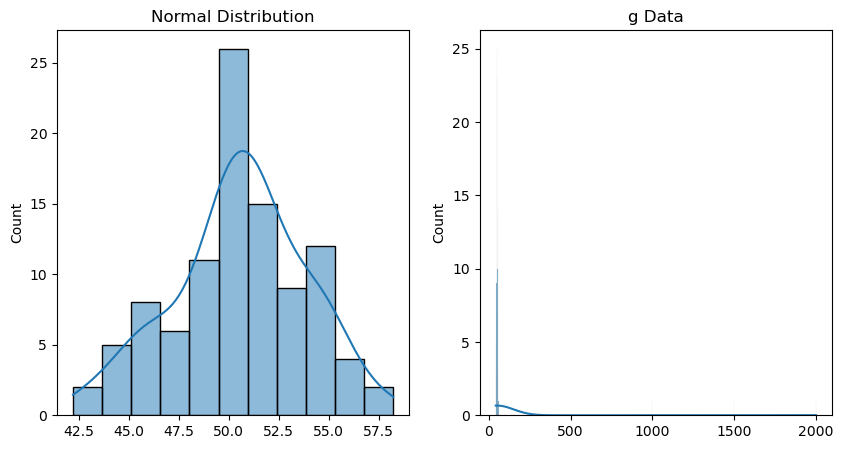

In [41]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(normal_dist,kde=True)
plt.title("Normal Distribution")
plt.subplot(1,2,2)
sns.histplot(g_data,kde=True)
plt.title("g Data")
plt.show()

In [42]:
from scipy.stats import skew

In [43]:
skew(normal_dist)

-0.2431349007350423

In [44]:
skew(g_data)

6.234275272081933

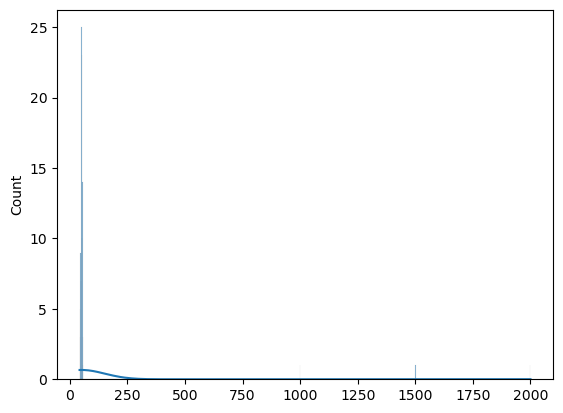

In [50]:
sns.histplot(g_data,kde=True)
plt.show()

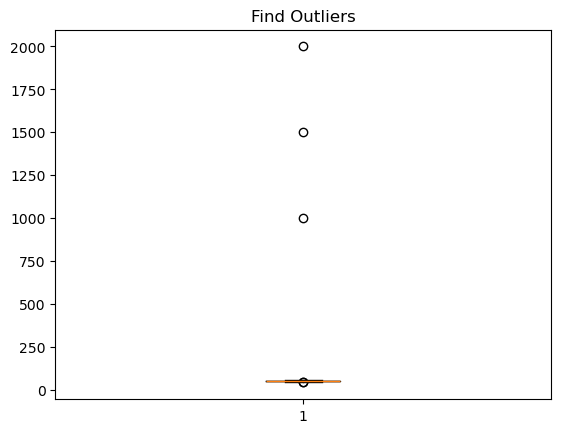

In [52]:
plt.boxplot(g_data)
plt.title("Find Outliers")
plt.show()

In [58]:
f=pd.DataFrame({"price_tag":a})
f

,price_tag
0,4200.0
1,7900.0
2,13300.0
3,23000.0
4,18300.0
...,...
4340,125000.0
4341,6500.0
4342,8000.0
4343,14200.0


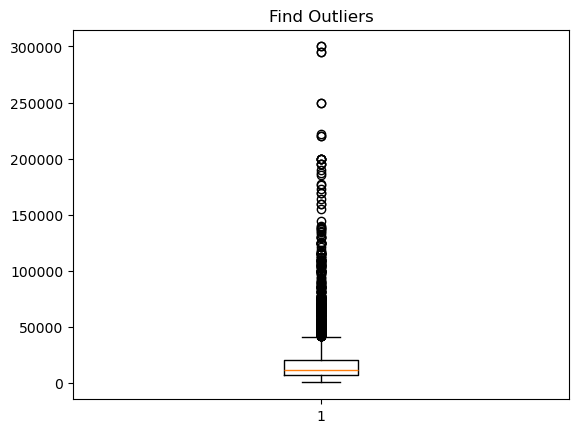

In [59]:
plt.boxplot(a)
plt.title("Find Outliers")
plt.show()

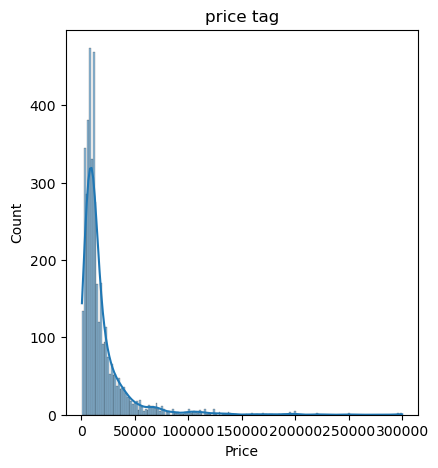

In [67]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(a,kde=True)
plt.title("price tag")
plt.show()